In [1]:
import sys, os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from data_processing import MelDataManager

data_folder = "../../data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']

In [2]:
mgr = MelDataManager(
    data_folder=data_folder,
    classes=classes,
    cache_path="../../data/processed/melspec_cache.npz",
    target_shape=(150, 150),
    chunk_duration=4,
    overlap_duration=2,
)

data, labels = mgr.load_or_build_cache()
print(f"Data shape: {data.shape}")
print(f"Labels shape (before one-hot): {labels.shape}")

Loaded cached data from ../../data/processed/melspec_cache.npz
Data shape: (14975, 150, 150, 1)
Labels shape (before one-hot): (14975,)


In [3]:
labels = mgr.one_hot()
print(f"Labels shape (one-hot): {labels.shape}")

Labels shape (one-hot): (14975, 10)


In [4]:
X_train, X_test, Y_train, Y_test = mgr.split(test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (11980, 150, 150, 1)
X_test shape: (2995, 150, 150, 1)
Y_train shape: (11980, 10)
Y_test shape: (2995, 10)


In [5]:
CNN_1 = tf.keras.models.load_model('../models/CNN_1.keras')

c:\Studia\Sem_5\Projektowe\GenreAI\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step


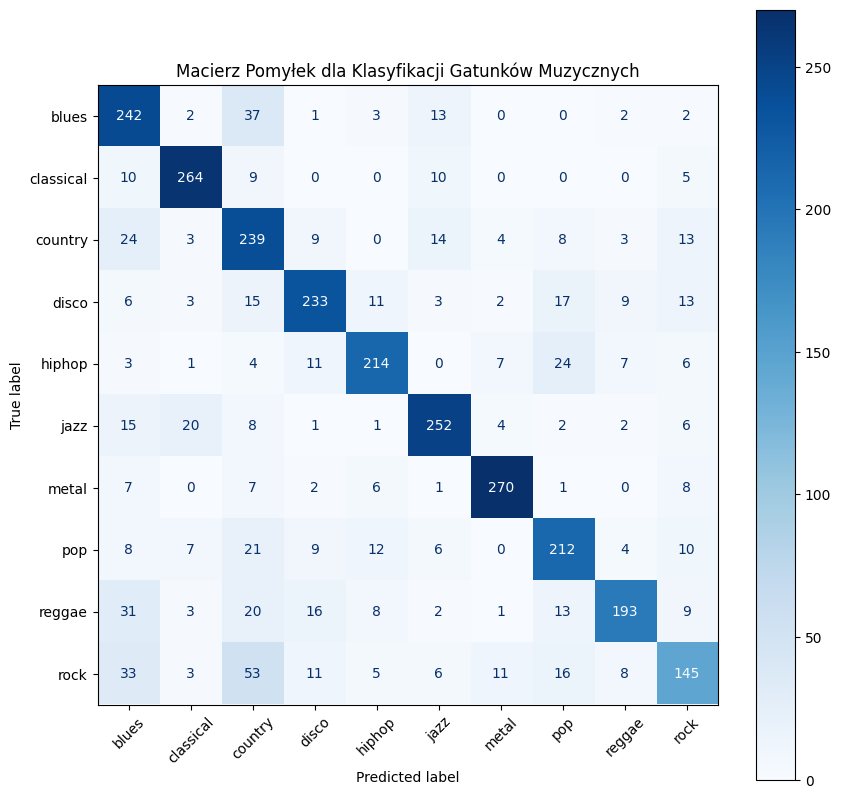

In [6]:
Y_pred_proba = CNN_1.predict(X_test)
Y_pred_classes = np.argmax(Y_pred_proba, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)
cm = confusion_matrix(Y_true_classes, Y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
cm_display.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Macierz Pomyłek dla Klasyfikacji Gatunków Muzycznych')
plt.xticks(rotation=45)
plt.show()